# Rozpoznawanie typów sygnałów dźwiękowych

### Załadowanie potrzebnych pakietów

In [60]:
import glob
import warnings
import wave
from os import path

import matplotlib.pyplot as plt
import pandas as pd
import pylab
from scipy.fftpack import fft
from scipy.io import wavfile as wav
from sklearn import ensemble, linear_model, metrics, svm
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')


### Narzędzia do eksploracji plików audio

In [61]:
def plot_spectrogram(audio_path: str):
    """
    Renderuje spektrogram dla wskazanego pliku WAV.
    """
    signal_values, sample_rate = read_wav_metadata(audio_path)
    pylab.figure(figsize=(15, 5))
    pylab.subplot(111)
    pylab.axis('off')
    pylab.title(f"Spektrogram: {audio_path}")
    pylab.xlabel('częstotliwość')
    pylab.ylabel('czas')
    pylab.specgram(signal_values, Fs=sample_rate)


def plot_wave(audio_path: str):
    """
    Pokazuje przebieg amplitudy sygnału audio w czasie.
    """
    signal_values, _ = read_wav_metadata(audio_path)
    plt.figure(num=1, figsize=(15, 5))
    plt.title(f"Przebieg sygnału: {audio_path}")
    plt.xlabel('czas')
    plt.ylabel('amplituda')
    plt.plot(signal_values)
    plt.show()


def plot_fft(audio_path: str):
    """
    Wyświetla moduł szybkiej transformaty Fouriera dla pliku audio.
    """
    fft_values = build_fft_vector(audio_path)
    fft_size = len(fft_values)
    plt.figure(figsize=(15, 5))
    plt.ylim(0, 50000)
    plt.title(f"FFT: {audio_path}")
    plt.xlabel('częstotliwość')
    plt.ylabel('amplituda')
    plt.plot(abs(fft_values[: int(fft_size) - 1]), 'r')
    plt.show()


def build_fft_vector(audio_path: str) -> list:
    """
    Zwraca wektor cech utworzony na bazie FFT.
    """
    _, raw_audio = wav.read(audio_path)
    left_channel = raw_audio.T[0]
    normalized_signal = [(sample / 2**8.0) * 2 - 1 for sample in left_channel]
    fft_result = fft(normalized_signal)
    half_length = len(fft_result) / 2
    return abs(fft_result[: int(half_length) - 1])


def read_wav_metadata(audio_path: str) -> tuple:
    """
    Odczytuje próbki dźwięku i częstotliwość próbkowania.
    """
    wav_handle = wave.open(audio_path, 'r')
    frame_buffer = wav_handle.readframes(-1)
    signal_values = pylab.fromstring(frame_buffer, 'int16')
    sample_rate = wav_handle.getframerate()
    wav_handle.close()
    return signal_values, sample_rate


### Przykład: syrena karetki

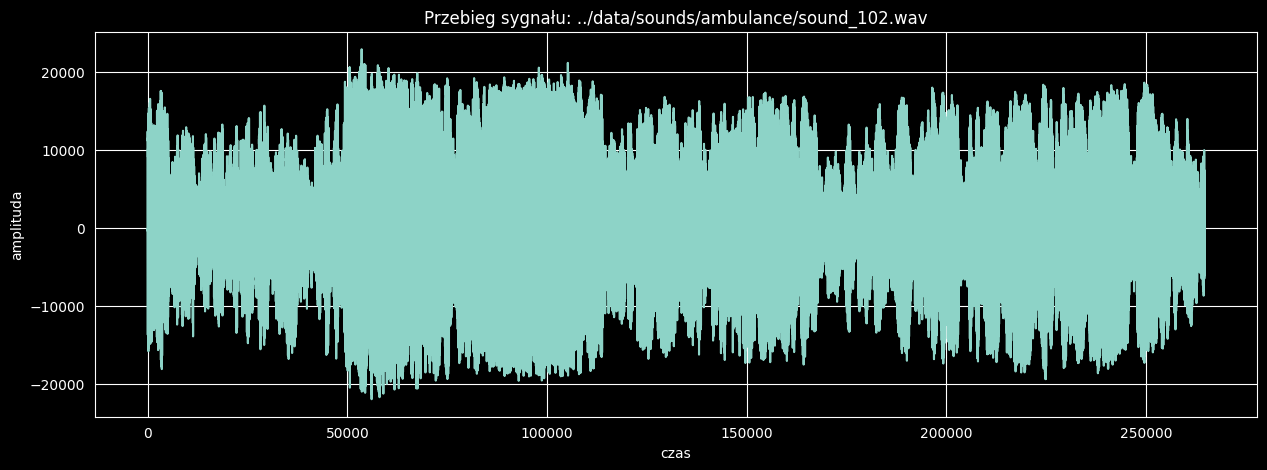

In [62]:
plot_wave('../data/sounds/ambulance/sound_102.wav')


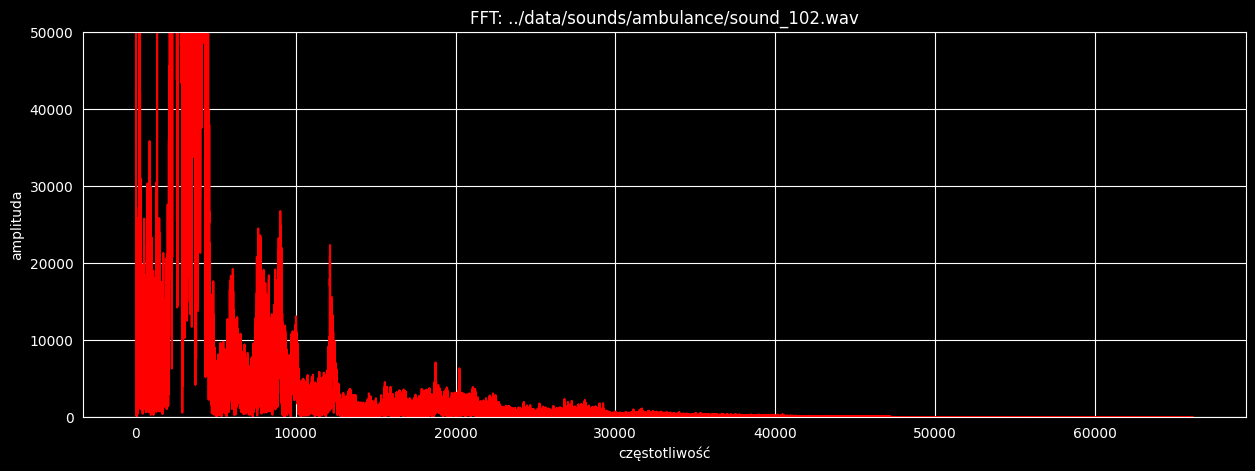

In [63]:
plot_fft('../data/sounds/ambulance/sound_102.wav')


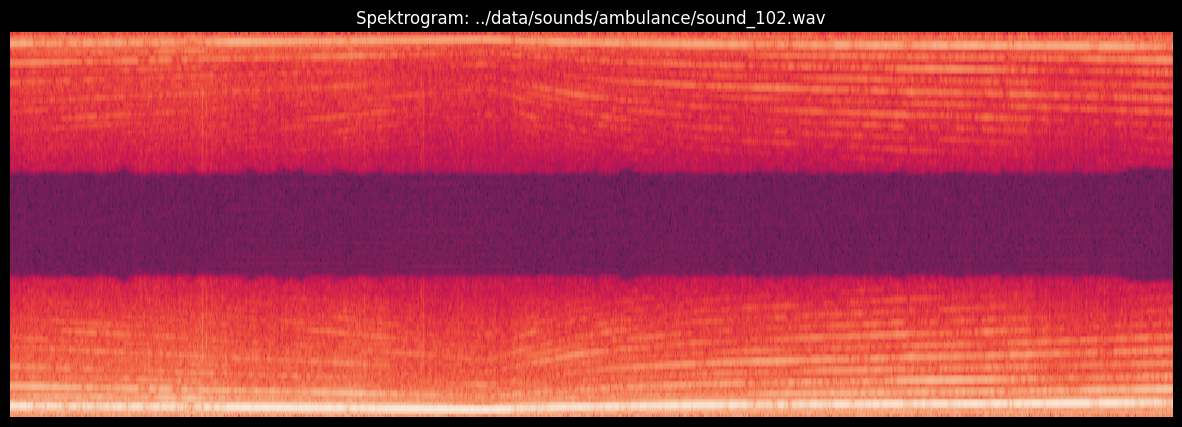

In [64]:
plot_spectrogram('../data/sounds/ambulance/sound_102.wav')


### Przykład: sygnał wozu strażackiego

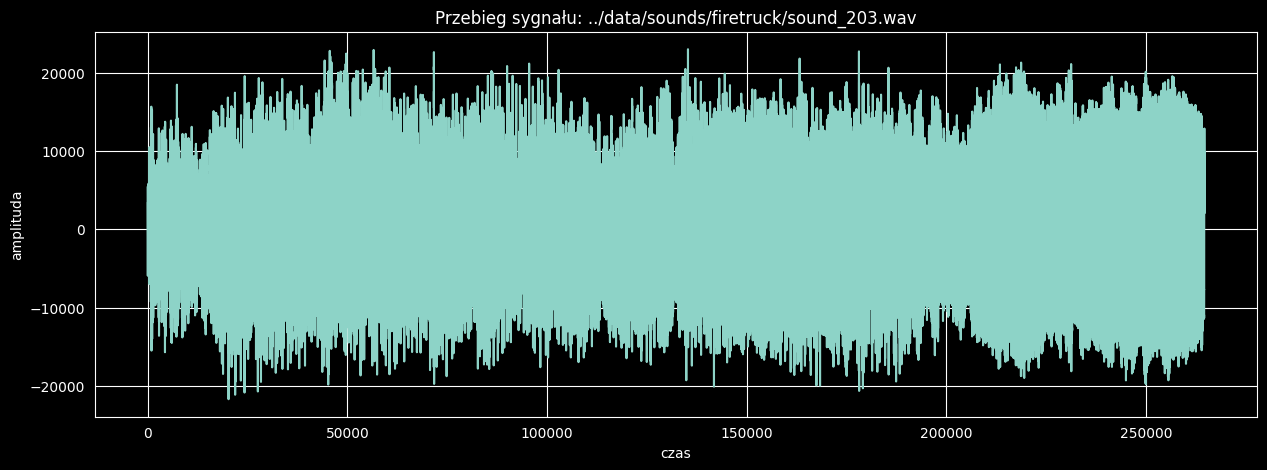

In [65]:
plot_wave('../data/sounds/firetruck/sound_203.wav')


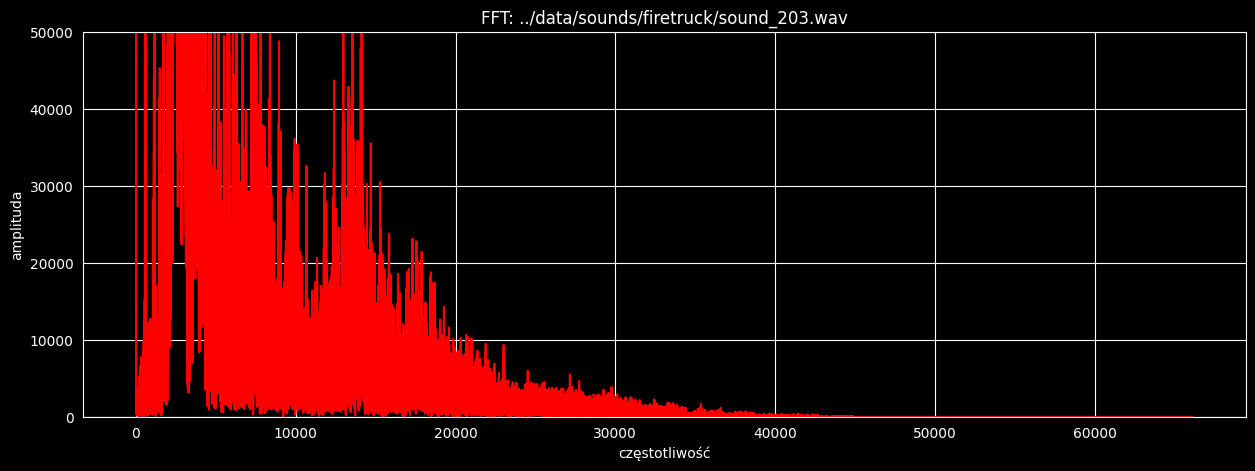

In [66]:
plot_fft('../data/sounds/firetruck/sound_203.wav')


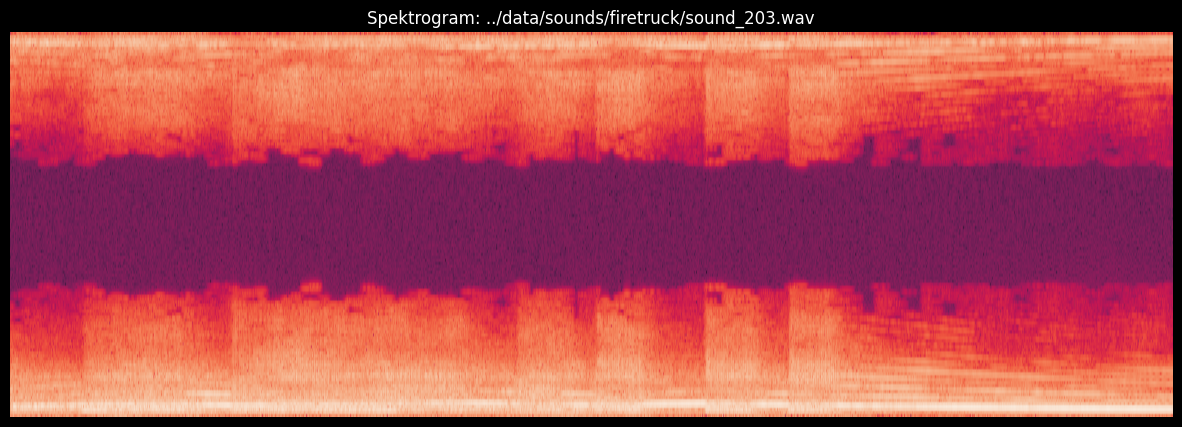

In [67]:
plot_spectrogram('../data/sounds/firetruck/sound_203.wav')


### Przykład: odgłosy ruchu ulicznego

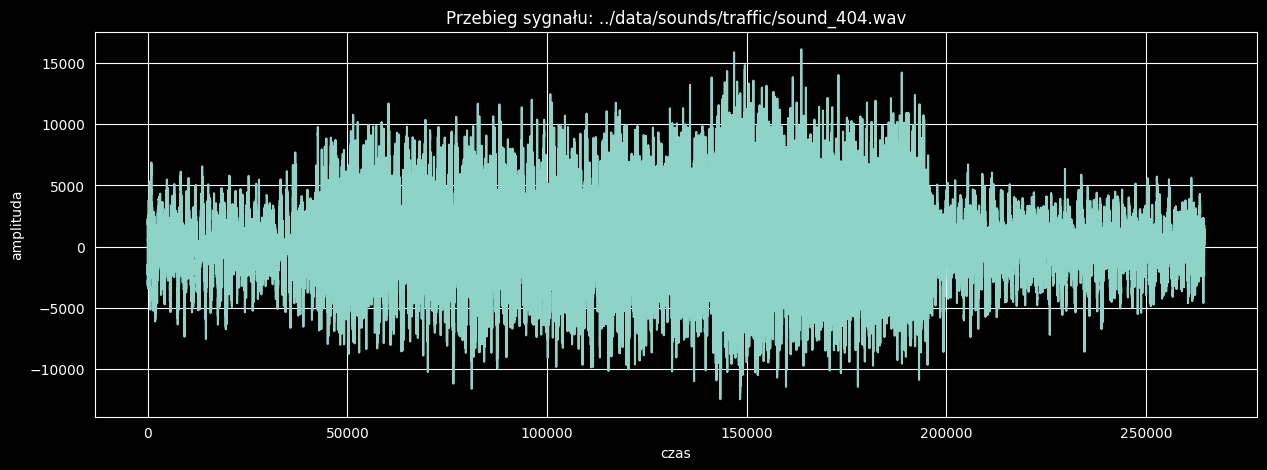

In [68]:
plot_wave('../data/sounds/traffic/sound_404.wav')


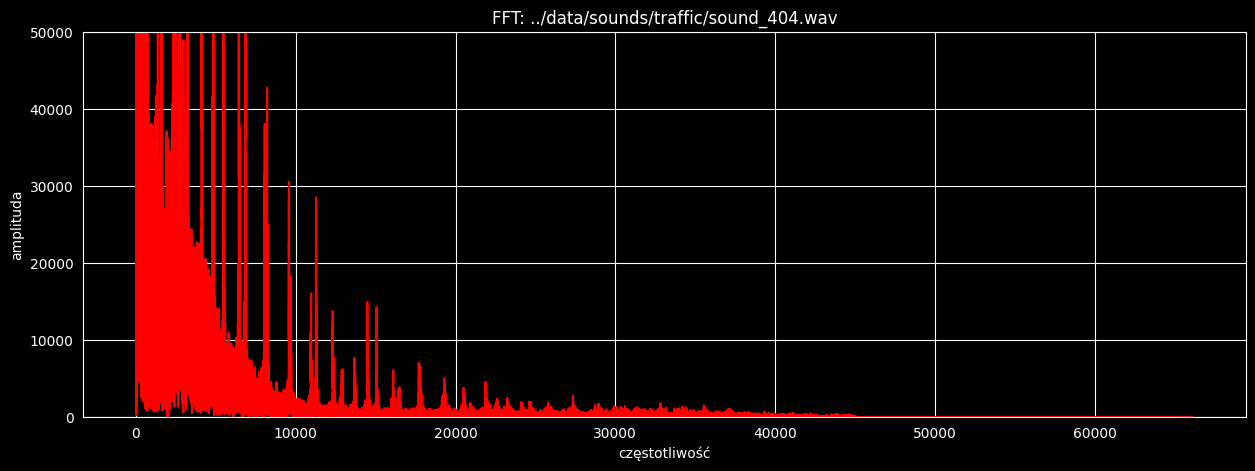

In [69]:
plot_fft('../data/sounds/traffic/sound_404.wav')


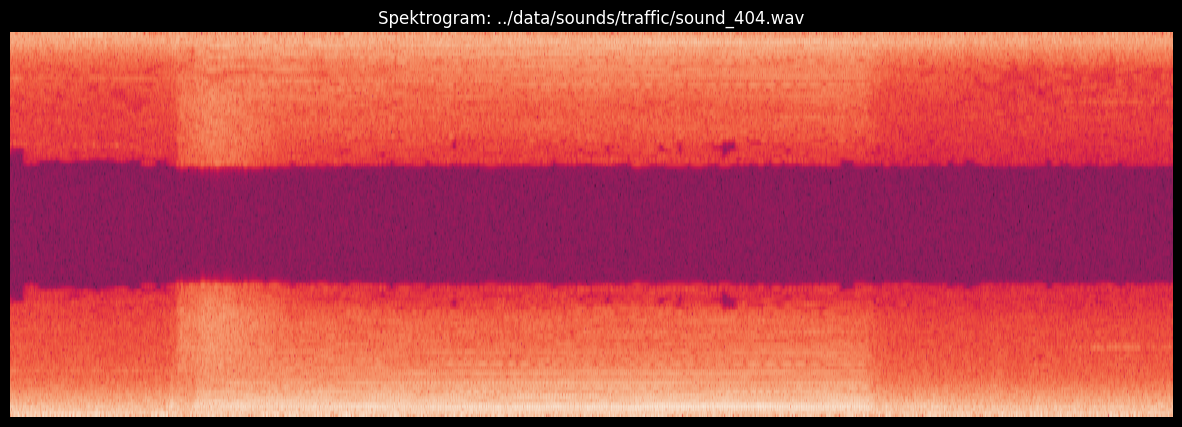

In [70]:
plot_spectrogram('../data/sounds/traffic/sound_404.wav')


### Budowa macierzy cech FFT i etykiet klas

In [71]:
feature_rows = []
class_labels = []

class_map = {
    'ambulance': 1,
    'firetruck': 2,
    'traffic': 3,
}


def collect_example(file_path):
    try:
        path_parts = file_path.split('/')
        feature_rows.append(build_fft_vector(file_path)[:50000:3])
        class_labels.append(class_map[path_parts[3]])
    except:
        pass


audio_files = glob.glob(path.join('', '../data/sounds/**/**'))
dataset_build = [collect_example(single_file) for single_file in tqdm(audio_files)]


  0%|          | 0/600 [00:00<?, ?it/s]

### Podział danych oraz procedura uczenia i oceny

In [72]:
train_features, test_features, train_labels, test_labels = train_test_split(
    feature_rows,
    class_labels,
    test_size=0.2,
    random_state=12345,
)


def fit_and_score(model, train_vectors, target_values, valid_vectors):
    # dopasowanie modelu do danych treningowych
    model.fit(train_vectors, target_values)

    # predykcje na części walidacyjnej
    predicted_labels = model.predict(valid_vectors)

    # obliczenie podstawowych miar jakości
    metric_values = list(metrics.precision_recall_fscore_support(predicted_labels, test_labels))
    summary_scores = [
        metric_values[0][0],
        metric_values[1][0],
        metric_values[2][0],
    ]
    summary_scores.append(metrics.accuracy_score(predicted_labels, test_labels))
    return model, summary_scores


### Test kilku podejść klasyfikacyjnych

In [73]:
# Wariant 1 - regresja logistyczna
_, model_scores = fit_and_score(
    linear_model.LogisticRegression(),
    train_features,
    train_labels,
    test_features,
)
results_by_model = {'LR': model_scores}
print('LR:', model_scores)


LR: [np.float64(0.9487179487179487), np.float64(0.9024390243902439), np.float64(0.925), 0.9401709401709402]


In [74]:
# Wariant 2 - SVM
_, model_scores = fit_and_score(
    svm.SVC(),
    train_features,
    train_labels,
    test_features,
)
results_by_model['SVM'] = model_scores
print('SVM', model_scores)


SVM [np.float64(0.8974358974358975), np.float64(0.8974358974358975), np.float64(0.8974358974358975), 0.9230769230769231]


In [75]:
# Wariant 3 - las losowy
best_model, model_scores = fit_and_score(
    ensemble.RandomForestClassifier(),
    train_features,
    train_labels,
    test_features,
)
results_by_model['RF'] = model_scores
print('RF:', model_scores)


RF: [np.float64(0.9487179487179487), np.float64(0.8809523809523809), np.float64(0.9135802469135802), 0.9316239316239316]


In [76]:
# Wariant 4 - prosta sieć neuronowa
from sklearn.neural_network import MLPClassifier

neural_model = MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=1000)
best_model, model_scores = fit_and_score(
    neural_model,
    train_features,
    train_labels,
    test_features,
)
results_by_model['neural network'] = model_scores
print('neural network', model_scores)


neural network [np.float64(0.717948717948718), np.float64(0.7), np.float64(0.7088607594936709), 0.49572649572649574]


### Zestawienie wyników modeli

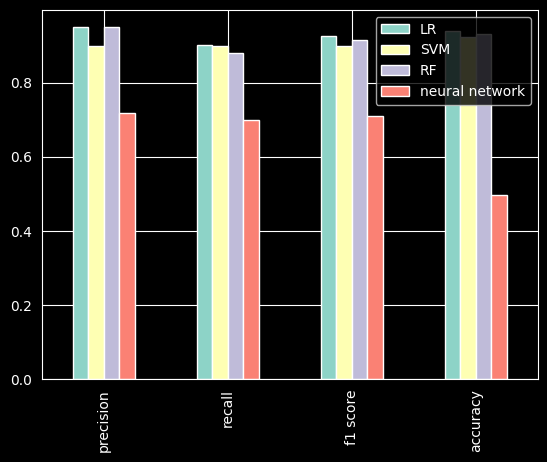

In [77]:
# porównanie miar dla wszystkich modeli
print(results_by_model)
comparison_frame = pd.DataFrame(
    results_by_model,
    index=['precision', 'recall', 'f1 score', 'accuracy'],
)
comparison_frame.plot(kind='bar')


### Szybki test predykcji na znanych próbkach

In [78]:
ambulance_fft = build_fft_vector('../data/sounds/ambulance/sound_102.wav')[:50000:3]
firetruck_fft = build_fft_vector('../data/sounds/firetruck/sound_203.wav')[:50000:3]
traffic_fft = build_fft_vector('../data/sounds/traffic/sound_404.wav')[:50000:3]

best_model.predict([ambulance_fft, firetruck_fft, traffic_fft])


array([1, 1, 3])